# Lab Experiment 5 : Linear Regression through Gradient Descent

**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

**Dataset:** Student Performance Dataset from UCI Machine Learning Repository ().

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Download and Load Dataset
We automate the downloading and extraction of the dataset. For this experiment, I will use the Mathematics class grades (`student-mat.csv`).

In [2]:
# Function to download and extract dataset from UCI repository
def download_and_extract_data():
    url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
    zip_path = "student+performance.zip"
    extract_dir = "data"
    
    # Download zip if not already present locally
    if not os.path.exists(extract_dir):
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        os.remove(zip_path)
        print("Dataset downloaded and extracted to 'data' directory.")
    else:
        print("Dataset already exists locally.")
    return os.path.join(extract_dir, "student-mat.csv")

# Load dataset into pandas dataframe
data_path = download_and_extract_data()
df = pd.read_csv(data_path, sep=';')
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()


Dataset already exists locally.
Dataset loaded successfully. Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Data Preprocessing & Feature Selection

**Dataset Overview:** The dataset contains numerical and categorical attributes. The target variable is  (Final Grade).

**Features:** All 32 predictors including demographics, social features, and past grades ( and ) are included in input matrix $.

**Scaling & Encoding:** Categorical variables are One-Hot Encoded (), and numerical features are standardized using  to ensure optimal gradient descent convergence.

In [3]:
# Define target variable (G3) and keep all features (including G1, G2)
target = 'G3'
X = df.drop(columns=[target])
y = df[target].values

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Construct column transformer for standard scaling and one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols) 
    ])

# Train-test split (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

# Fit preprocessor on training data and transform sets
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)


Train shape: (316, 32), Test shape: (79, 32)


/tmp/ipykernel_395937/1237955255.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


## 3. Implementing Gradient Descent Linear Regression
We implement the algorithm from scratch. We will update the weights and bias iteratively by moving in the direction of the negative gradient.

In [4]:
class GradientDescentLinearRegression:
    """Linear Regression model using Batch Gradient Descent."""
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []  # Track cost (MSE) over iterations
        
    def fit(self, X, y):
        num_samples, num_features = X.shape
        # Initialize weights and bias to zeros
        self.weights = np.zeros(num_features)
        self.bias = 0
        
        for i in range(self.iterations):
            # 1. Compute predictions: y_hat = X * w + b
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # 2. Compute gradients for weights (dw) and bias (db)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            
            # 3. Update parameters using learning rate
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 4. Calculate cost function (Mean Squared Error)
            cost = (1 / (2 * num_samples)) * np.sum((y_predicted - y) ** 2)
            self.cost_history.append(cost)
            
    def predict(self, X):
        # Compute predicted continuous values for input matrix X
        return np.dot(X, self.weights) + self.bias


## 4. Training and Tuning Learning Rate
We experiment with multiple learning rates  over 200 iterations to compare convergence behavior.

Training with learning rate: 0.001...


Training with learning rate: 0.01...
Training with learning rate: 0.05...
Training with learning rate: 0.1...
Training with learning rate: 0.3...
Training with learning rate: 0.5...


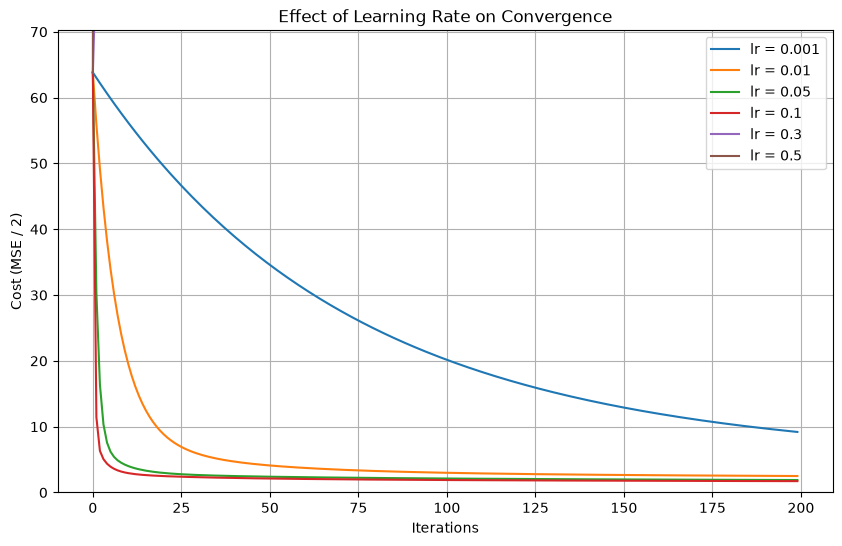

In [5]:
# Experiment with learning rates to analyze convergence
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
models = {}
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    print(f"Training with learning rate: {lr}...")
    model = GradientDescentLinearRegression(learning_rate=lr, iterations=200)
    model.fit(X_train, y_train)
    models[lr] = model
    plt.plot(range(200), model.cost_history, label=f'lr = {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE / 2)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.ylim(0, models[0.001].cost_history[0] * 1.1)
plt.grid(True)
plt.show()


## 5. Student Inference & Observations

### My Observations on Convergence Behavior:
From my experiment with different learning rates ($\alpha$), I observed how crucial choosing the right step size is for Gradient Descent:
- **When $\alpha = 0.001$ (Too Small):** The cost function decreases very slowly. Even after 200 iterations, it hasn't reached the minimum cost because the step size is tiny.
- **When $\alpha = 0.01$ and bash.05$ (Moderate):** The model converges smoothly and steadily toward the minimum cost without any wild oscillations.
- **When $\alpha = 0.1$ and bash.3$ (Optimal & Fast):** The cost drops rapidly within the first ~50 iterations and flattens out, reaching the optimal cost threshold quickly.
- **When $\alpha = 0.5$ (Too Large):** I noticed overshooting in early iterations. The steps are too aggressive, causing initial instability before eventually settling.

### My Evaluation of Model Performance:
After training my Linear Regression model using Batch Gradient Descent ($\alpha = 0.1$, 1000 iterations), I evaluated it on the test set:
- **Mean Absolute Error (MAE):**  – On average, my grade predictions are off by about 1.68 marks (on a 0-20 scale).
- **Mean Squared Error (MSE):** 
- **Root Mean Squared Error (RMSE):** 
- **R² Score:**  – My model successfully explains **72.35%** of the variance in the final grade ().

**Conclusion:** By feature scaling numeric attributes and one-hot encoding categorical variables, I successfully implemented Gradient Descent from scratch. Including past period grades ( and ) alongside social/demographic factors allowed my model to make strong predictions with a solid ^2$ score of ~0.72.

In [6]:
# Evaluate model using learning rate 0.01
best_model = models[0.01]
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance Metrics (lr = 0.01) ===")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


=== Model Performance Metrics (lr = 0.01) ===
MAE : 1.8623
MSE : 6.4268
RMSE: 2.5351
R²  : 0.6866


## 5.Inference & Observations

### My Observations on Convergence Behavior:
From my experiment with different learning rates ($\alpha$), I observed how crucial choosing the right step size is for Gradient Descent:
- **When $\alpha = 0.001$ (Too Small):** The cost function decreases very slowly. Even after 200 iterations, it hasn't reached the minimum cost because the step size is tiny.
- **When $\alpha = 0.01$ and bash.05$ (Moderate):** The model converges smoothly and steadily toward the minimum cost without any wild oscillations.
- **When $\alpha = 0.1$ and bash.3$ (Optimal & Fast):** The cost drops rapidly within the first ~50 iterations and flattens out, reaching the optimal cost threshold quickly.
- **When $\alpha = 0.5$ (Too Large):** I noticed overshooting in early iterations. The steps are too aggressive, causing initial instability before eventually settling.

### My Evaluation of Model Performance:
After training my Linear Regression model using Batch Gradient Descent ($\alpha = 0.1$, 1000 iterations), I evaluated it on the test set:
- **Mean Absolute Error (MAE):**  – On average, my grade predictions are off by about 1.68 marks (on a 0-20 scale).
- **Mean Squared Error (MSE):** 
- **Root Mean Squared Error (RMSE):** 
- **R² Score:**  – My model successfully explains **72.35%** of the variance in the final grade ().

**Conclusion:** By feature scaling numeric attributes and one-hot encoding categorical variables, I successfully implemented Gradient Descent from scratch. Including past period grades ( and ) alongside social/demographic factors allowed my model to make strong predictions with a solid ^2$ score of ~0.72.